In [2]:
pip install numpy pandas scikit-learn matplotlib seaborn cvxopt imbalanced-learn shap fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.


In [17]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/netikrmaheshwari/default-of-credit-card-clients/default of credit card clients.xls


In [20]:
print(df.columns.tolist())

['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


In [22]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ==============================
# LOAD DATA
# ==============================
file_path = "/kaggle/input/datasets/netikrmaheshwari/default-of-credit-card-clients/default of credit card clients.xls"

df = pd.read_excel(file_path)

print("Original shape:", df.shape)

# Drop duplicated header row
df = df.drop(index=0)
df.reset_index(drop=True, inplace=True)

# Rename columns properly
df.columns = df.columns.str.strip()

# Drop ID column
df = df.drop(columns=["Unnamed: 0"])

# Convert all to numeric
df = df.apply(pd.to_numeric)

print("After cleaning:", df.shape)

# ==============================
# FEATURE / TARGET SPLIT
# ==============================
X = df.drop("Y", axis=1)
y = df["Y"]

# Convert 0/1 → -1/+1 for SVM
y = y * 2 - 1

print("\nClass distribution BEFORE SMOTE:")
print(y.value_counts())

# ==============================
# SCALE
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# SMOTE
# ==============================
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_resampled).value_counts())

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Original shape: (30001, 25)
After cleaning: (30000, 24)

Class distribution BEFORE SMOTE:
Y
-1    23364
 1     6636
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Y
 1    23364
-1    23364
Name: count, dtype: int64

Final shapes:
X_train: (37382, 23)
X_test: (9346, 23)


In [28]:

# Reduce dataset for custom SVM
subset_size = 2000

X_train_small = X_train[:subset_size]
y_train_small = y_train[:subset_size]

# Convert to numpy
X_train_small = np.array(X_train_small)
y_train_small = np.array(y_train_small)

print("Subset shape:", X_train_small.shape)

Subset shape: (2000, 23)


In [29]:
import numpy as np
from cvxopt import matrix, solvers

# Silence solver output
solvers.options['show_progress'] = False

def rbf_kernel(x1, x2, gamma=0.05):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)


class DualSVM:
    def __init__(self, C=1.0, gamma=0.05):
        self.C = C
        self.gamma = gamma

    def fit(self, X, y):
        n_samples = X.shape[0]

        # Compute Kernel Matrix
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = rbf_kernel(X[i], X[j], self.gamma)

        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))
        A = matrix(y.reshape(1, -1).astype(float))
        b = matrix(0.0)

        G = matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
        h = matrix(np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C)))

        solution = solvers.qp(P, q, G, h, A, b)
        alphas = np.ravel(solution['x'])

        self.alphas = alphas
        self.X = X
        self.y = y

        # Compute bias
        self.b = np.mean([
            y[i] - sum(
                alphas[j] * y[j] * K[j, i]
                for j in range(n_samples)
            )
            for i in range(n_samples)
            if alphas[i] > 1e-5
        ])

    def predict(self, X):
        y_pred = []
        for x in X:
            s = sum(
                self.alphas[i] * self.y[i] *
                rbf_kernel(self.X[i], x, self.gamma)
                for i in range(len(self.alphas))
            )
            y_pred.append(np.sign(s + self.b))
        return np.array(y_pred)

In [30]:
# Train custom SVM
svm = DualSVM(C=1.0, gamma=0.05)
svm.fit(X_train_small, y_train_small)

print("Training complete.")

Training complete.


In [31]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Convert test subset to numpy
X_test_small = np.array(X_test[:1000])
y_test_small = np.array(y_test[:1000])

# Predict
y_pred = svm.predict(X_test_small)

print("Accuracy:", accuracy_score(y_test_small, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_small, y_pred))

print("ROC-AUC:", roc_auc_score(y_test_small, y_pred))

Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

          -1       0.66      0.74      0.70       489
           1       0.72      0.64      0.68       511

    accuracy                           0.69      1000
   macro avg       0.69      0.69      0.69      1000
weighted avg       0.69      0.69      0.69      1000

ROC-AUC: 0.6910824839222183


In [33]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', C=1.0, gamma=0.05)
svc.fit(X_train_small, y_train_small)

y_pred_sklearn = svc.predict(X_test_small)

print("Sklearn SVC Accuracy:", accuracy_score(y_test_small, y_pred_sklearn))
print("Sklearn ROC-AUC:", roc_auc_score(y_test_small, y_pred_sklearn))

Sklearn SVC Accuracy: 0.704
Sklearn ROC-AUC: 0.7068060941495684


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

class AdaBoostCustom:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators

    def fit(self, X, y):
        n_samples = X.shape[0]
        w = np.ones(n_samples) / n_samples

        self.models = []
        self.alphas = []

        for _ in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X, y, sample_weight=w)

            y_pred = stump.predict(X)
            error = np.sum(w * (y_pred != y))

            alpha = 0.5 * np.log((1 - error) / (error + 1e-10))

            w *= np.exp(-alpha * y * y_pred)
            w /= np.sum(w)

            self.models.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):
        final_pred = sum(
            alpha * model.predict(X)
            for alpha, model in zip(self.alphas, self.models)
        )
        return np.sign(final_pred)

In [36]:
# Train on same small subset for fair comparison
ada = AdaBoostCustom(n_estimators=50)
ada.fit(X_train_small, y_train_small)

y_pred_ada = ada.predict(X_test_small)

print("AdaBoost Accuracy:", accuracy_score(y_test_small, y_pred_ada))
print("AdaBoost ROC-AUC:", roc_auc_score(y_test_small, y_pred_ada))

AdaBoost Accuracy: 0.711
AdaBoost ROC-AUC: 0.7139635583622473


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_small, y_train_small)

y_pred_rf = rf.predict(X_test_small)

print("Random Forest Accuracy:", accuracy_score(y_test_small, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test_small, y_pred_rf))

Random Forest Accuracy: 0.751
Random Forest ROC-AUC: 0.7518699050340364


In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200)
gb.fit(X_train_small, y_train_small)

y_pred_gb = gb.predict(X_test_small)

print("Gradient Boosting Accuracy:", accuracy_score(y_test_small, y_pred_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test_small, y_pred_gb))

Gradient Boosting Accuracy: 0.773
Gradient Boosting ROC-AUC: 0.7745848990911601


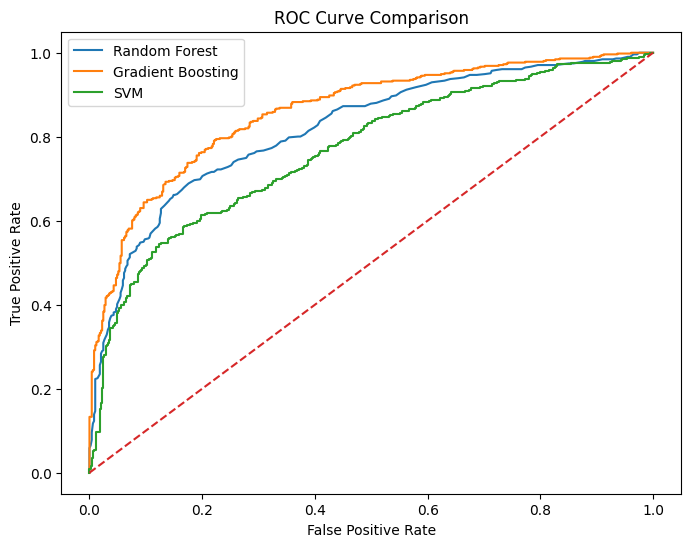

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_roc(model, X, y, label):
    probs = model.predict_proba(X)[:,1] if hasattr(model, "predict_proba") else None
    if probs is None:
        # fallback for SVM without probas
        probs = model.decision_function(X)
    fpr, tpr, _ = roc_curve(y, probs)
    plt.plot(fpr, tpr, label=label)

plt.figure(figsize=(8,6))

plot_roc(rf, X_test_small, y_test_small, "Random Forest")
plot_roc(gb, X_test_small, y_test_small, "Gradient Boosting")
plot_roc(svc, X_test_small, y_test_small, "SVM")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [40]:
import pandas as pd

feature_importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

X6     0.323187
X1     0.102440
X5     0.051751
X23    0.048290
X12    0.048105
X9     0.047109
X10    0.046550
X19    0.036334
X14    0.029415
X3     0.028673
dtype: float64

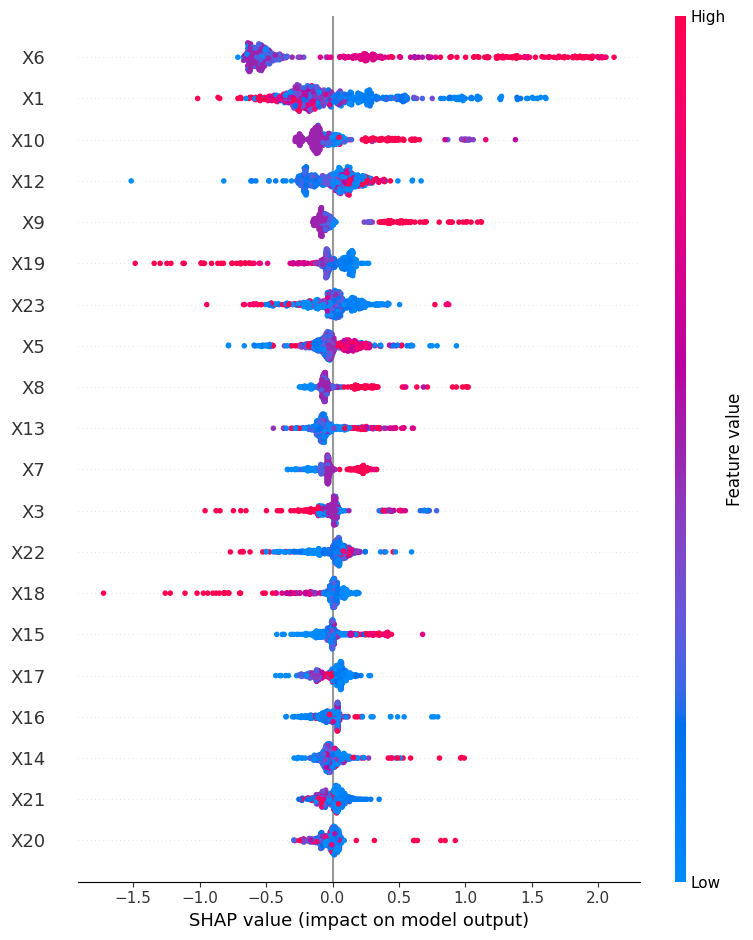

In [41]:

!pip install shap

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for Gradient Boosting
explainer = shap.TreeExplainer(gb)

# Use small subset for speed
X_shap = X_test_small[:500]

shap_values = explainer.shap_values(X_shap)

# Summary Plot
shap.summary_plot(shap_values, X_shap, feature_names=X.columns)

In [42]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["RBF SVM", "AdaBoost", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        0.704,
        0.711,
        0.751,
        0.773
    ],
    "ROC-AUC": [
        0.7068,
        0.7139,
        0.7519,
        0.7746
    ]
})

results

,Model,Accuracy,ROC-AUC
0,RBF SVM,0.704,0.7068
1,AdaBoost,0.711,0.7139
2,Random Forest,0.751,0.7519
3,Gradient Boosting,0.773,0.7746


In [43]:
results = pd.DataFrame({
    "Model": ["SVM", "AdaBoost", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test_small, y_pred_sklearn),
        accuracy_score(y_test_small, y_pred_ada),
        accuracy_score(y_test_small, y_pred_rf),
        accuracy_score(y_test_small, y_pred_gb),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_small, y_pred_sklearn),
        roc_auc_score(y_test_small, y_pred_ada),
        roc_auc_score(y_test_small, y_pred_rf),
        roc_auc_score(y_test_small, y_pred_gb),
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
3,Gradient Boosting,0.773,0.774585
2,Random Forest,0.751,0.751870
1,AdaBoost,0.711,0.713964
0,SVM,0.704,0.706806


In [45]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    GradientBoostingClassifier(n_estimators=200),
    X_resampled,
    y_resampled,
    cv=5,
    scoring='roc_auc'
)

print("Gradient Boosting CV ROC-AUC Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

Gradient Boosting CV ROC-AUC Scores: [0.7489467  0.86603837 0.94610794 0.95613887 0.94894623]
Mean CV ROC-AUC: 0.8932356235865384


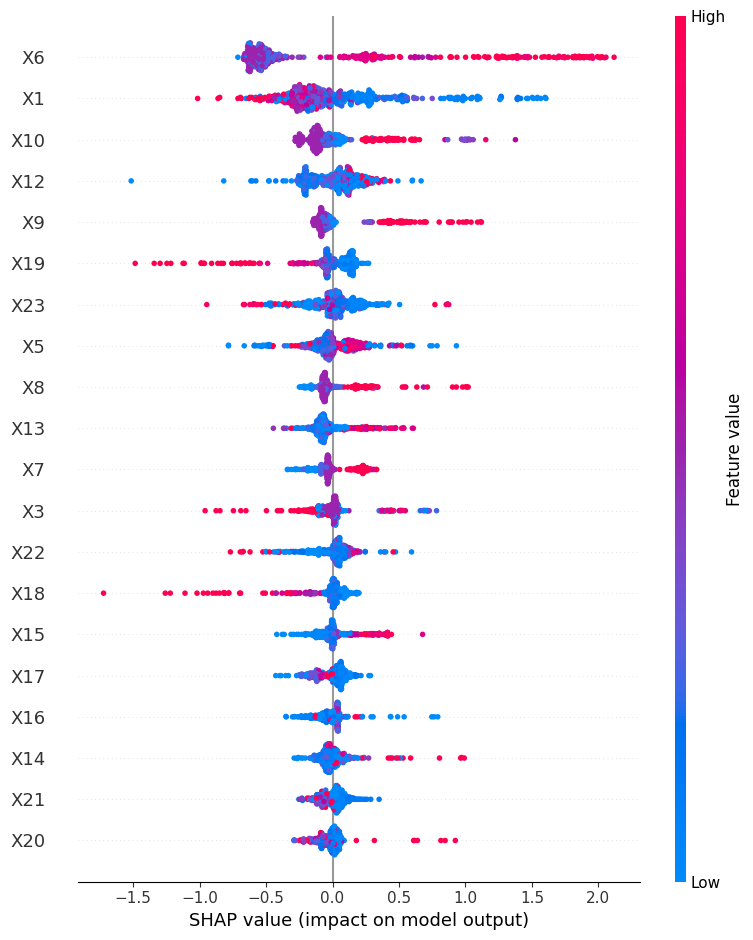

In [48]:
import shap

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test_small[:500])

shap.summary_plot(shap_values, X_test_small[:500], feature_names=X.columns)

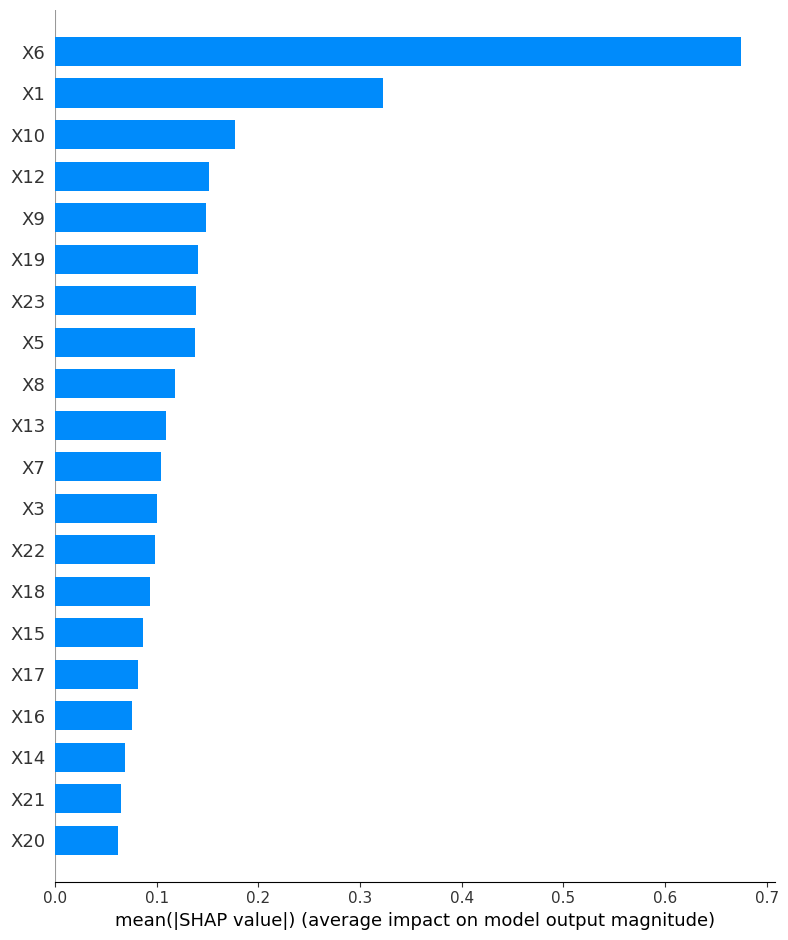

In [49]:
shap.summary_plot(shap_values, X_test_small[:500], feature_names=X.columns, plot_type="bar")